<ipython-input-2-5366ac883995>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Date"][i] = datetime_date_from_numeric(date)
D:\anaconda3\lib\site-packages\pandas\core\indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


dropped 15 columns with missing interior values
took 2.9241671562194824
              mean       std
0111145D  0.028849 -0.086678
0202445Q  0.239369 -0.058264
0203524D -0.048854  0.017398
0226226D -0.196985 -0.005679
0376152D  0.140355  0.002373
...            ...       ...
ZBH       0.092001 -0.077926
ZION      0.016281 -0.028574
ZRN       0.020990 -0.085435
ZTS       0.765497 -0.088776
ZTS-W     0.280530 -0.137652

[1162 rows x 2 columns]


,Date,0111145D,0202445Q,0203524D,0226226D,0376152D,0440296D,0544749D,0574018D,0598884D,...,XYL,YNR,YRCW,YUM,YUMC,ZBH,ZION,ZRN,ZTS,ZTS-W
0,1993-09-07,13.2719,13.6829,8.4429,8.1042,11.000,57.3245,17.8887,6.8315,28.1246,...,NaN,NaN,144439.5121,NaN,NaN,NaN,7.1675,30.7970,NaN,NaN
1,1993-09-08,13.3263,13.5315,8.2147,7.9590,11.000,57.2096,17.8064,6.8315,27.5051,...,NaN,NaN,143691.1208,NaN,NaN,NaN,6.9766,30.0188,NaN,NaN
2,1993-09-09,13.7070,13.3800,8.7852,8.0627,11.125,59.1625,17.6831,6.8315,27.7529,...,NaN,NaN,143691.1208,NaN,NaN,NaN,6.9554,30.0188,NaN,NaN
3,1993-09-10,13.3807,13.4810,9.4127,8.0368,11.125,59.6220,17.6420,6.8773,27.5051,...,NaN,NaN,145187.9033,NaN,NaN,NaN,7.2099,29.6852,NaN,NaN
4,1993-09-13,13.4894,13.6829,9.2416,8.0368,11.125,59.8518,17.3541,6.8773,27.8768,...,NaN,NaN,148181.4684,NaN,NaN,NaN,7.2523,29.0988,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6524,2019-07-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,82.34,NaN,3.3600,112.66,44.40,125.83,43.5100,NaN,115.44,NaN
6525,2019-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,81.67,NaN,3.2500,112.89,44.83,123.91,44.2500,NaN,114.65,NaN
6526,2019-07-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,81.48,NaN,3.3500,114.02,45.31,134.50,45.1600,NaN,115.11,NaN
6527,2019-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,80.89,NaN,3.1800,114.10,45.43,134.53,44.6500,NaN,115.55,NaN


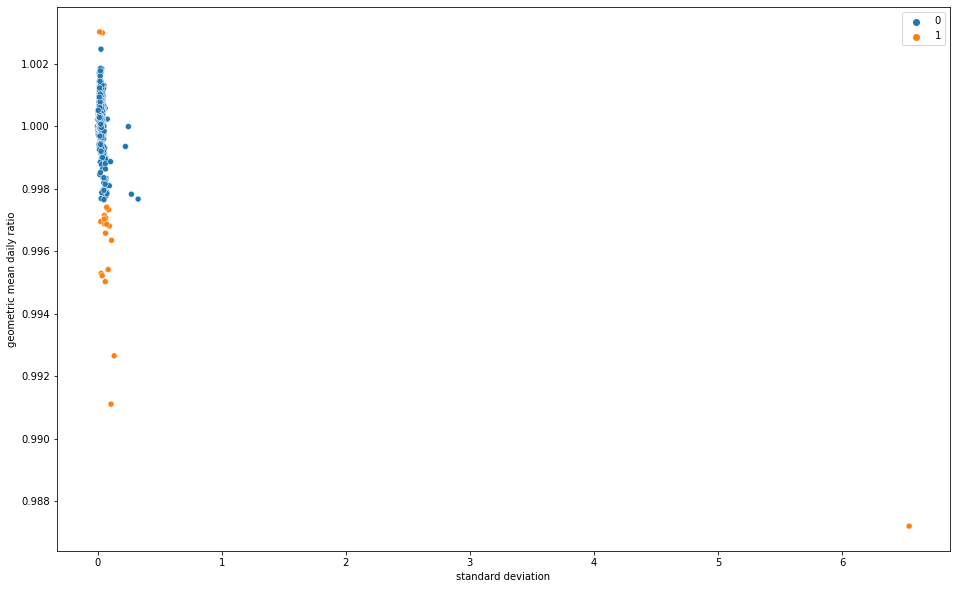

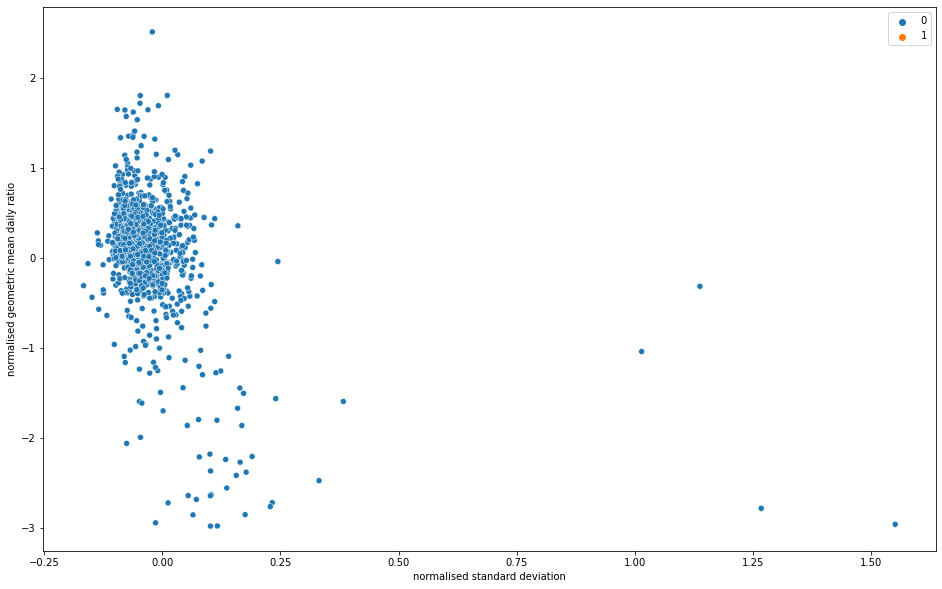

In [2]:
import pandas as pd
import numpy as np
import random

import numba as nb

import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import time
import re

dt = datetime.date
t0 = time.time()

def datetime_date_from_numeric(n):
    n = str(n)
    year = int(n[0:4])
    month = int(n[4:6])
    day = int(n[6:8])
    return datetime.date(year, month, day)

def ticker_exists(data, ticker, start=datetime.date(1993,9,7), end=datetime.date(2019,7,31)):
    sub = data[["Date", ticker]]
    return len(sub[sub["Date"] > start][sub["Date"] < end].dropna()) == (end-start-datetime.timedelta(days=1)).days

def time_range(data, start_date, end_date):
    return data[data["Date"] > start_date][data["Date"] <= end_date]

def tickers_all():
    tickers = data.columns.tolist()
    tickers.drop("Date")
    return tickers

filename = "adjprice.csv"
data = pd.read_csv(filename)

i = 0
for date in data["Date"]:
#     print(date)
    data["Date"][i] = datetime_date_from_numeric(date)
#     print(data["datetime_date"][i])
    i+=1
# data

rename_dict = {}
for column_name in data.columns:
    rename_dict[column_name] = column_name.replace(" US Equity", "")
data = data.rename(columns=rename_dict)

# remove weekends
# weekend_mask = data.apply(func = lambda x: (((x["Date"] - datetime.date(2021,9,18))%datetime.timedelta(days=7)).days <= 1), axis=1)

no_change_rows = data.index[1:][(np.diff(data.fillna(0).drop("Date", axis=1), axis=0)==0).all(axis=1)]
data.drop(no_change_rows, inplace=True)
data.reset_index(inplace=True)

# indices = data.index[weekend_mask]
# data = data.drop(indices).reset_index()
data.drop("index", axis=1, inplace=True)
# data





# slow and expensive way to calculate NaN-boundaries. takes 15-30 seconds to execute.

# na_boundaries = {}
# for ticker in tickers_all:
#     nan_array = np.isnan(data[ticker])
    
#     start = 0
#     while nan_array[start] == True:
#         start += 1
    
#     end = len(data) - 1
#     while nan_array[end] == True:
#         end -= 1
#     na_boundaries[ticker] = [start, end]
# #     print(ticker, start, end)

# a = pd.DataFrame(na_boundaries)
# interior_len = a.T[1] - a.T[0]
# has_missing_interior_values = []
has_missing_interior_values = ['231330Q',
 'AVATQ',
 'CHIR',
 'CNRG',
 'DELL',
 'DOW',
 'FOX',
 'FOXA',
 'GIDL',
 'GTGOF',
 'HCR',
 'LK',
 'PD',
 'PLL',
 'PVT']
# for ticker in tickers_all:
#     is_missing_val = len(data[ticker].dropna()) < interior_len[ticker]
#     if is_missing_val:
#         has_missing_interior_values.append(ticker)
    
#     if is_missing_val:
#         print(f"{ticker} is missing interior values")

data.drop(has_missing_interior_values, axis=1, inplace=True)

tickers_all = list(data.columns)
tickers_all.remove("Date")

print(f"dropped {len(has_missing_interior_values)} columns with missing interior values")
print("took " + str(time.time() - t0))
data





# dropping stocks based on z-scores
def ddt(a):
    return (a / a.shift(1)).shift(-1).dropna()

def ddt_inverse(a):
    out = [1]
    for item in a:
        out.append(out[-1]*item)
    return np.array(out)


def geo_mean(arr):
        prod = arr.prod()
        return np.sign(prod)*(np.abs(prod))**(1/len(arr))
# tticker = random.sample(list(data.columns[1:]),1)[0]
ticker_stats = {}
for tticker in tickers_all:
# tticker = "QCOM"
    ticker_data = data[tticker]
    T = ticker_data.dropna()
    dT = ddt(T)
    dT_norm = (dT-dT.mean())/dT.std()
    prod = dT.prod()
    
    ticker_stats[tticker] = [geo_mean(dT), dT.std()]
#     print(len(dT))

#     hist_data = dT_norm.plot.hist(figsize=(16,10),bins=500)
#     plt.xlim((-5,5))
#     hist_data

# plt.figure(figsize=(16,10))
# plt.scatter(x=coord_df.T[0], y=coord_df.T[1])
# plt.xlabel("mean change")
# plt.ylabel("standard deviation")

a = pd.DataFrame(ticker_stats)
a.index = ["mean", "std"]
# a = a.T[np.abs(a.T["mean"])>1.1].T
a

plotable_data = (a.T).copy()

plt.figure(figsize=(16,10))
plt.ylabel("geometric mean daily ratio")
plt.xlabel("standard deviation")

desc_mean = [plotable_data["mean"].mean(), plotable_data["mean"].std()]
desc_std = [plotable_data["std"].mean(), plotable_data["std"].std()]
# plt.scatter(x=a.T["mean"], y=a.T["std"])


norm_mean = (plotable_data["mean"] - desc_mean[0])/desc_mean[1]
norm_std = (plotable_data["std"] - desc_std[0])/desc_std[1]
mask = ((np.abs(norm_std) <= 3) & (np.abs(norm_mean) <= 3)).astype(np.int32)*-1 + 1


sns.scatterplot(x=plotable_data["std"], y=plotable_data["mean"], hue=mask)

plotable_data["mean"] = norm_mean
plotable_data["std"] = norm_std

for ticker_i in range(len(tickers_all)):
#     print(tickers_all[ticker_i], mask[ticker_i])
    if mask[ticker_i]: plotable_data.drop(tickers_all[ticker_i], inplace=True)
    None

plt.figure(figsize=(16,10))
sns.scatterplot(x=plotable_data["std"], y=plotable_data["mean"], hue=mask)
plt.ylabel("normalised geometric mean daily ratio")
plt.xlabel("normalised standard deviation")
print(plotable_data)

drop_ticker_list = []
for ticker_i in range(len(tickers_all)):
    if mask[ticker_i]: drop_ticker_list.append(tickers_all[ticker_i])
data.drop(drop_ticker_list, axis=1, inplace=True)
data

In [ ]:
corrs = data.drop("Date", axis=1).corr()

In [14]:
corrs

,0111145D,0202445Q,0203524D,0226226D,0376152D,0440296D,0544749D,0574018D,0598884D,0772031D,...,XYL,YNR,YRCW,YUM,YUMC,ZBH,ZION,ZRN,ZTS,ZTS-W
0111145D,1.000000,0.871481,0.619134,0.617312,0.770243,0.745089,0.722626,0.904544,0.898746,-0.429726,...,-9.523250e-02,-0.218261,-0.219947,0.951879,NaN,0.162076,0.153333,0.858631,NaN,NaN
0202445Q,0.871481,1.000000,0.618054,0.548796,0.771488,0.883241,0.746530,0.885176,0.055365,-0.324303,...,NaN,0.701869,0.070744,0.830872,NaN,0.310725,0.375937,0.124785,NaN,NaN
0203524D,0.619134,0.618054,1.000000,0.580047,0.620491,-0.242688,0.628956,0.682287,-0.198450,-0.019093,...,4.048259e-15,0.681827,0.215964,0.453717,NaN,0.615602,0.422356,0.138568,NaN,NaN
0226226D,0.617312,0.548796,0.580047,1.000000,0.869704,-0.015954,0.670745,0.639630,0.935308,-0.479784,...,NaN,-0.402518,0.909850,0.317643,NaN,0.658204,0.824910,0.968767,NaN,NaN
0376152D,0.770243,0.771488,0.620491,0.869704,1.000000,0.609313,0.724963,0.911601,-0.629625,-0.640209,...,NaN,0.039181,0.833871,0.926137,NaN,0.729374,0.712684,-0.352395,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZBH,0.162076,0.310725,0.615602,0.658204,0.729374,NaN,0.375023,0.633557,NaN,-0.194211,...,7.679156e-01,NaN,-0.311962,0.828794,0.378384,1.000000,0.168770,NaN,0.684669,0.217440
ZION,0.153333,0.375937,0.422356,0.824910,0.712684,0.956179,0.666102,0.711823,0.947475,0.006580,...,9.343151e-01,0.117846,0.589011,-0.146218,0.548813,0.168770,1.000000,0.880556,0.857383,0.453060
ZRN,0.858631,0.124785,0.138568,0.968767,-0.352395,-0.068916,0.490610,0.766012,0.906269,0.803301,...,NaN,0.327706,0.298549,0.380663,NaN,NaN,0.880556,1.000000,NaN,NaN
ZTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.553598e-01,NaN,-0.633914,0.975789,0.658118,0.684669,0.857383,NaN,1.000000,0.060745


In [ ]:
corr_pairs = {}
index = corrs.index
for i1 in index:
    for i2 in index:
        if i1 != i2:
            corr_pairs[f"{i1}_{i2}"] = corrs[i1][i2]
# corr_pairs = pd.DataFrame(corr_pairs)

In [42]:
pd.Series(corr_pairs).sort_values(ascending=False).head(50)

GOOGL_GOOG       0.999478
GOOG_GOOGL       0.999478
RTN_RTN/B        0.999399
RTN/B_RTN        0.999399
BHI_BHGE         0.999224
BHGE_BHI         0.999224
MNST_1288453D    0.998963
1288453D_MNST    0.998963
TFCFA_TFCF       0.997442
TFCF_TFCFA       0.997442
CMCSK_CMCSA      0.997164
CMCSA_CMCSK      0.997164
EQR_AVB          0.996663
AVB_EQR          0.996663
AWK_XEL          0.996244
XEL_AWK          0.996244
LNT_WEC          0.995012
WEC_LNT          0.995012
DTE_PNW          0.995001
PNW_DTE          0.995001
LNT_DTE          0.994874
DTE_LNT          0.994874
WEC_CHD          0.994516
CHD_WEC          0.994516
WEC_ES           0.994429
ES_WEC           0.994429
V_ADP            0.994371
ADP_V            0.994371
WEC_AWK          0.994237
AWK_WEC          0.994237
DTE_WEC          0.994177
WEC_DTE          0.994177
SPG_FRT          0.994061
FRT_SPG          0.994061
CMS_AWK          0.993969
AWK_CMS          0.993969
V_MA             0.993905
MA_V             0.993905
UAA_UA      

Text(0, 0.5, 'Stock Price (USD)')

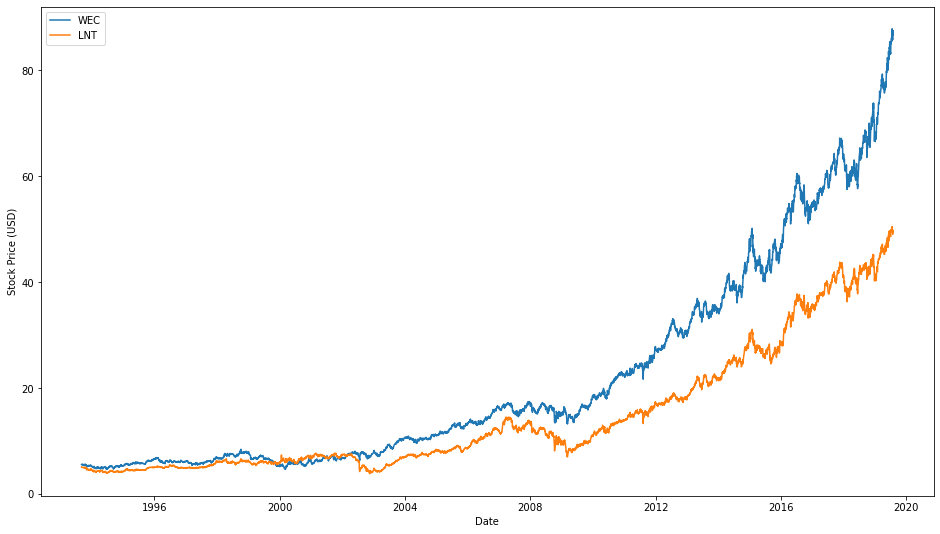

In [5]:
# data.plot(x="Date", y=["WEC", "LNT"], figsize=(16,9))
data.plot(x="Date", y=["WEC", "LNT"], figsize=(16,9))
plt.ylabel("Stock Price (USD)")

In [45]:
filename = "adjprice.csv"
raw = pd.read_csv(filename)

In [55]:
raw.iloc[50:60]

,Date,0111145D US Equity,0202445Q US Equity,0203524D US Equity,0226226D US Equity,0376152D US Equity,0440296D US Equity,0544749D US Equity,0574018D US Equity,0598884D US Equity,...,YNR US Equity,YRCW US Equity,YUM US Equity,YUMC US Equity,ZBH US Equity,ZETHQ US Equity,ZION US Equity,ZRN US Equity,ZTS US Equity,ZTS-W US Equity
50,19931027,12.2521,14.0951,7.8154,9.2553,11.000,53.5335,16.8606,7.5920,28.7441,...,NaN,139087.5082,NaN,NaN,NaN,7.375,7.2150,23.8386,NaN,NaN
51,19931028,12.2521,14.0443,7.5872,9.2294,10.750,53.5335,16.7784,7.5457,28.6202,...,NaN,139843.4185,NaN,NaN,NaN,7.500,7.2364,24.1744,NaN,NaN
52,19931029,12.4170,14.0951,7.6443,9.2034,11.125,53.4186,16.5727,7.4531,28.2485,...,NaN,139087.5082,NaN,NaN,NaN,7.875,7.4712,24.1744,NaN,NaN
53,19931030,12.4170,14.0951,7.6443,9.2034,11.125,53.4186,16.5727,7.4531,28.2485,...,NaN,139087.5082,NaN,NaN,NaN,7.875,7.4712,24.1744,NaN,NaN
54,19931031,12.4170,14.0951,7.6443,9.2034,11.125,53.4186,16.5727,7.4531,28.2485,...,NaN,139087.5082,NaN,NaN,NaN,7.875,7.4712,24.1744,NaN,NaN
55,19931101,12.6367,14.0443,7.9866,9.2294,10.875,54.5674,16.5727,7.4531,28.4963,...,NaN,140599.3289,NaN,NaN,NaN,7.750,7.3858,24.1744,NaN,NaN
56,19931102,12.4170,13.9936,7.9866,9.0479,10.625,53.7632,16.4905,7.3605,28.2485,...,NaN,141355.2393,NaN,NaN,NaN,7.625,7.4712,24.1744,NaN,NaN
57,19931103,12.1423,13.8922,7.3020,8.6849,10.750,52.1411,16.1204,7.2680,27.6290,...,NaN,140599.3289,NaN,NaN,NaN,7.375,6.7241,24.0624,NaN,NaN
58,19931104,12.2521,13.8922,7.1309,8.1146,10.875,50.1713,15.6680,7.2217,26.7617,...,NaN,139087.5082,NaN,NaN,NaN,7.125,6.8735,23.9505,NaN,NaN
59,19931105,12.0324,13.7908,7.3020,8.1146,10.500,52.0252,15.7503,7.2217,26.7617,...,NaN,137575.6874,NaN,NaN,NaN,7.000,6.7881,23.3909,NaN,NaN


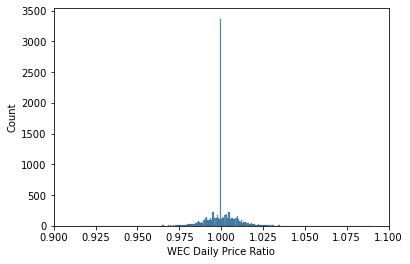

In [60]:
t = ddt(raw["WEC US Equity"])
# sns.histplot((t-t.mean())/t.std(), label="DVA")
sns.histplot(t)
plt.xlabel("WEC Daily Price Ratio")
plt.xlim((0.9,1.1))
# plt.ylim((0,500))
# plt.legend()
t.mean(), t.std()
plt.savefig("WEC all dist")

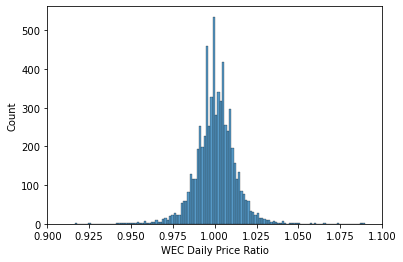

In [61]:
t = ddt(data["WEC"])
# sns.histplot((t-t.mean())/t.std(), label="DVA")
sns.histplot(t)
plt.xlabel("WEC Daily Price Ratio")
plt.xlim((0.9,1.1))
# plt.ylim((0,500))
# plt.legend()
t.mean(), t.std()
plt.savefig("WEC weekday dist")

In [ ]:
YYYY MM DD
1993 10 30